# Scaleworm Detection Verification Lab

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

This notebook runs the YOLO "Mushroom Model" on CAMHD video frames and lets you verify each detection. Your job is to look at each cropped detection and decide: **is this a scale worm, or not?**

**Workflow:**
1. **Choose your date range** — pick which days of video to analyze
2. **Extract frames** — pull Scene 1 frames from each video (the Mushroom vent zoom)
3. **Run the detector** — YOLO finds candidate scale worms at low confidence (catches more, but includes false positives)
4. **Verify each detection** — you'll see each crop at multiple zoom levels and mark it as worm or not-worm
5. **Export** — verified true detections are packaged as a YOLO-format dataset for downstream training

</span>

## 0. Model Progress

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

Run this section at the start of any session to see how worm counts and detection quality have changed across model versions. **You do not need to re-run the rest of the notebook first** — these cells read from saved output files.

- **Cross-round comparison** — verified worm counts per day for all completed rounds on one chart. As the model improves, you expect the lines to converge toward consistent counts and the false-positive rate to fall.
- **Per-round detail** — worm count over time, false-positive rate, and confidence distribution for a single selected round. The confidence histogram is especially useful: a better model pushes real worm detections toward high confidence (>0.7) and false positives toward low confidence (<0.3).

</span>

In [1]:
# ── CROSS-ROUND COMPARISON ────────────────────────────────────────
# Verified worm counts per day for every completed round on one chart.
# Add a new entry to ROUNDS each time a round is finished and exported.

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "plotly"], check=True)

import re
from pathlib import Path
import plotly.graph_objects as go

# Okabe-Ito colorblind-safe palette
_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]

ROUNDS = [
    {"session_dir": Path("verification_session"),    "label": "Round 1 — mushroom.pt (v0)"},
    {"session_dir": Path("verification_session_r2"), "label": "Round 2 — retrained_v1"},
]


def _count_worms_by_date(session_dir):
    """Return {date_str: worm_count} from verified export label files."""
    label_dir = Path(session_dir) / "export" / "labels" / "train"
    if not label_dir.exists():
        return {}
    counts = {}
    for f in sorted(label_dir.glob("*.txt")):
        m = re.search(r"(\d{4})(\d{2})(\d{2})T", f.name)
        if not m:
            continue
        date = f"{m.group(1)}-{m.group(2)}-{m.group(3)}"
        n = sum(1 for ln in f.read_text().splitlines() if ln.strip())
        counts[date] = counts.get(date, 0) + n
    return counts


fig = go.Figure()
any_data = False

for i, r in enumerate(ROUNDS):
    counts = _count_worms_by_date(r["session_dir"])
    if not counts:
        print(f"No export data yet for: {r['label']} — run Steps 6–8 first.")
        continue
    any_data = True
    dates = sorted(counts)
    fig.add_trace(go.Scatter(
        x=dates,
        y=[counts[d] for d in dates],
        mode="lines+markers",
        name=r["label"],
        line=dict(color=_COLORS[i % len(_COLORS)], width=2),
        marker=dict(size=5),
    ))

if any_data:
    fig.update_layout(
        title="Verified scale worm detections per day — all model versions",
        xaxis_title="Date",
        yaxis_title="Worm detections (verified)",
        hovermode="x unified",
        template="plotly_white",
        height=420,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    )
    fig.show()
else:
    print("No completed rounds found yet.")

No export data yet for: Round 2 — retrained_v1 — run Steps 6–8 first.


### Per-round detail

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

Shows three panels for whichever round you set in `DETAIL_ROUND`:

- **Worm count per day** — how many verified worms were found each day across the month
- **False-positive rate per day** — fraction of detections that turned out not to be worms; lower is better
- **Confidence distribution** — histogram of the model's confidence score for real worms vs. false positives; a well-trained model shows clear separation (worms at high confidence, FPs at low)

Change `DETAIL_ROUND["session_dir"]` to switch between rounds.

</span>

In [2]:
# ── PER-ROUND DETAIL ──────────────────────────────────────────────
# Worm count per day, confidence distribution, and FP rate for one round.
# Change DETAIL_ROUND to inspect a different session.

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "plotly"], check=True)

from collections import defaultdict
from pathlib import Path
import json, re, statistics
from plotly.subplots import make_subplots
import plotly.graph_objects as go

DETAIL_ROUND = {
    "session_dir": Path("verification_session"),
    "label":       "Round 1 — mushroom.pt (v0)",
}

session_dir = Path(DETAIL_ROUND["session_dir"])
det_file    = session_dir / "all_detections.json"
prog_file   = session_dir / "verification_progress.json"

if not prog_file.exists():
    print(f"No verification progress found at {prog_file}")
    print("Complete verification (Step 6) before running this cell.")
else:
    with open(prog_file) as f:
        labels = json.load(f).get("labels", {})   # {str(idx): label}

    # ── Load detection metadata ────────────────────────────────────
    if det_file.exists():
        with open(det_file) as f:
            detections = json.load(f)
        for i, det in enumerate(detections):
            det["label"] = labels.get(str(i))
            m = re.search(r"(\d{4})(\d{2})(\d{2})T", det.get("video", ""))
            det["date"] = f"{m.group(1)}-{m.group(2)}-{m.group(3)}" if m else None
        has_conf = True
    else:
        # Fallback: reconstruct from export labels (no confidence available)
        print("Note: confidence data not available — all_detections.json missing.")
        print("It will be saved automatically from round 2 onwards.\n")
        detections = []
        label_dir = session_dir / "export" / "labels" / "train"
        if label_dir.exists():
            for f in sorted(label_dir.glob("*.txt")):
                m = re.search(r"(\d{4})(\d{2})(\d{2})T", f.name)
                if not m:
                    continue
                date = f"{m.group(1)}-{m.group(2)}-{m.group(3)}"
                for _ in range(sum(1 for ln in f.read_text().splitlines() if ln.strip())):
                    detections.append({"date": date, "label": "scale_worm", "conf": None})
        has_conf = False

    # ── Aggregate ──────────────────────────────────────────────────
    date_worm, date_not, date_skip = defaultdict(int), defaultdict(int), defaultdict(int)
    conf_worm, conf_not = [], []

    for det in detections:
        date, label, conf = det.get("date"), det.get("label"), det.get("conf")
        if date is None:
            continue
        if label == "scale_worm":
            date_worm[date] += 1
            if conf is not None: conf_worm.append(conf)
        elif label == "not_worm":
            date_not[date] += 1
            if conf is not None: conf_not.append(conf)
        elif label == "skip":
            date_skip[date] += 1

    all_dates = sorted(set(list(date_worm) + list(date_not) + list(date_skip)))

    # ── Build subplots ─────────────────────────────────────────────
    n_rows = 3 if has_conf else 2
    titles = [
        f"{DETAIL_ROUND['label']} — verified worm detections per day",
        "False-positive rate per day (%)",
    ]
    if n_rows == 3:
        titles.append("Detection confidence distribution")

    fig = make_subplots(rows=n_rows, cols=1, subplot_titles=titles,
                        vertical_spacing=0.12)

    # Row 1: worm count per day
    fig.add_trace(go.Scatter(
        x=all_dates, y=[date_worm[d] for d in all_dates],
        mode="lines+markers", name="scale_worm",
        line=dict(color="#0072B2", width=2), marker=dict(size=5),
    ), row=1, col=1)

    # Row 2: FP rate per day
    fp_rates = [
        100 * date_not[d] / (date_worm[d] + date_not[d])
        if (date_worm[d] + date_not[d]) > 0 else None
        for d in all_dates
    ]
    fig.add_trace(go.Scatter(
        x=all_dates, y=fp_rates,
        mode="lines+markers", name="FP rate",
        line=dict(color="#D55E00", width=2), marker=dict(size=5),
    ), row=2, col=1)

    # Row 3: confidence histograms
    if n_rows == 3:
        for conf_vals, name, color in [
            (conf_worm, "scale_worm", "#0072B2"),
            (conf_not,  "not_worm",   "#D55E00"),
        ]:
            if conf_vals:
                fig.add_trace(go.Histogram(
                    x=conf_vals, name=name,
                    marker_color=color, opacity=0.7,
                    xbins=dict(start=0, end=1, size=0.05),
                ), row=3, col=1)

    fig.update_xaxes(title_text="Date",             row=1, col=1)
    fig.update_yaxes(title_text="Worm detections",  row=1, col=1)
    fig.update_xaxes(title_text="Date",             row=2, col=1)
    fig.update_yaxes(title_text="FP rate (%)",      row=2, col=1)
    if n_rows == 3:
        fig.update_xaxes(title_text="Confidence",   row=3, col=1)
        fig.update_yaxes(title_text="Count",        row=3, col=1)

    fig.update_layout(
        template="plotly_white",
        height=280 * n_rows + 80,
        barmode="overlay",
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.01, xanchor="right", x=1),
    )
    fig.show()

    # ── Summary stats ──────────────────────────────────────────────
    tw, tn, ts = sum(date_worm.values()), sum(date_not.values()), sum(date_skip.values())
    print(f"\n{'='*52}")
    print(f"  {DETAIL_ROUND['label']}")
    print(f"{'='*52}")
    print(f"  Verified worms:       {tw:,}")
    print(f"  Not worm (FP):        {tn:,}")
    print(f"  Skipped:              {ts:,}")
    if tw + tn > 0:
        print(f"  Overall FP rate:      {100*tn/(tw+tn):.1f}%")
    if conf_worm:
        print(f"  Median conf (worm):   {statistics.median(conf_worm):.3f}")
    if conf_not:
        print(f"  Median conf (FP):     {statistics.median(conf_not):.3f}")
    print(f"{'='*52}")

Note: confidence data not available — all_detections.json missing.
It will be saved automatically from round 2 onwards.




  Round 1 — mushroom.pt (v0)
  Verified worms:       3,671
  Not worm (FP):        0
  Skipped:              0
  Overall FP rate:      0.0%


## 1. Setup

In [3]:
import json
import re
import shutil
import subprocess
import zipfile
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
from PIL import Image

# ── Configuration ───────────────────────────────────────────────────
# Round 2: retrained model from round 1 verification
MODEL_PATH = Path("runs/detect/verification_session/runs/scaleworm_retrained_v1/weights/best.pt")

# Video archive root
VIDEO_ROOT = Path("/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/")

# Working directory for this session (round 2 — keeps round 1 data intact)
WORK_DIR = Path("./verification_session_r2")
FRAMES_DIR = WORK_DIR / "frames"
CROPS_DIR = WORK_DIR / "crops"
EXPORT_DIR = WORK_DIR / "export"

# Frame extraction parameters
SCENE1_START_SEC = 305   # Scene 1 start offset in each video
SCENE1_DURATION_SEC = 15  # Scene 1 duration
FPS = 1                  # Frames per second to extract
FRAME_W, FRAME_H = 1920, 1080

# Detection parameters
CONF_THRESHOLD = 0.1      # Low threshold to catch more candidates
MAX_BOX_SIZE = 300        # Filter out boxes larger than this (not real worms)

# Standard 3-hour cadence times (UTC)
STANDARD_TIMES = {
    "T001500", "T031500", "T061500", "T091500",
    "T121500", "T151500", "T181500", "T211500",
}

for d in [WORK_DIR, FRAMES_DIR, CROPS_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Model:     {MODEL_PATH}")
print(f"Exists:    {MODEL_PATH.exists()}")
print(f"Video root: {VIDEO_ROOT}")
print(f"Exists:    {VIDEO_ROOT.exists()}")
print(f"Work dir:  {WORK_DIR.resolve()}")
print(f"Conf threshold: {CONF_THRESHOLD}")

Model:     runs/detect/verification_session/runs/scaleworm_retrained_v1/weights/best.pt
Exists:    True
Video root: /home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301
Exists:    True
Work dir:  /home/jovyan/scaleworm-student-lab/notebooks/verification_session_r2
Conf threshold: 0.1


## 2. Choose your date range

<span style="font-family: 'Courier New', monospace;">

Run the cell below to see which dates have video available, then set your start and end dates.

</span>

In [4]:
def find_videos(video_root, start_date, end_date):
    """Find standard-cadence CAMHD videos between two dates (inclusive).

    Parameters
    ----------
    video_root : Path
        Root of the CAMHD archive (contains year/month/day subdirs).
    start_date : str
        Start date as 'YYYY-MM-DD'.
    end_date : str
        End date as 'YYYY-MM-DD'.

    Returns
    -------
    list of Path
        Sorted list of video file paths.
    """
    import datetime
    d_start = datetime.date.fromisoformat(start_date)
    d_end = datetime.date.fromisoformat(end_date)

    videos = []
    for mp4 in sorted(video_root.rglob("CAMHDA301-*.mp4")):
        m = re.search(r"CAMHDA301-(\d{4})(\d{2})(\d{2})T(\d{6})", mp4.name)
        if not m:
            continue
        y, mo, d, time_str = m.group(1), m.group(2), m.group(3), m.group(4)
        file_date = datetime.date(int(y), int(mo), int(d))

        if file_date < d_start or file_date > d_end:
            continue

        # Only keep standard 3-hour cadence times
        if f"T{time_str}" not in STANDARD_TIMES:
            continue

        videos.append(mp4)

    return sorted(videos)


# ════════════════════════════════════════════════════════════════════
# ▼▼▼  SET YOUR DATE RANGE HERE  ▼▼▼
# ════════════════════════════════════════════════════════════════════

START_DATE = "2024-10-01"   # First day to analyze (YYYY-MM-DD)
END_DATE   = "2024-10-31"   # Last day to analyze (YYYY-MM-DD)

# ════════════════════════════════════════════════════════════════════

videos = find_videos(VIDEO_ROOT, START_DATE, END_DATE)

print(f"Found {len(videos)} standard-cadence videos "
      f"between {START_DATE} and {END_DATE}:\n")
for v in videos:
    print(f"  {v.name}")

Found 247 standard-cadence videos between 2024-10-01 and 2024-10-31:

  CAMHDA301-20241001T031500.mp4
  CAMHDA301-20241001T061500.mp4
  CAMHDA301-20241001T091500.mp4
  CAMHDA301-20241001T121500.mp4
  CAMHDA301-20241001T151500.mp4
  CAMHDA301-20241001T181500.mp4
  CAMHDA301-20241001T211500.mp4
  CAMHDA301-20241002T001500.mp4
  CAMHDA301-20241002T031500.mp4
  CAMHDA301-20241002T061500.mp4
  CAMHDA301-20241002T091500.mp4
  CAMHDA301-20241002T121500.mp4
  CAMHDA301-20241002T151500.mp4
  CAMHDA301-20241002T181500.mp4
  CAMHDA301-20241002T211500.mp4
  CAMHDA301-20241003T001500.mp4
  CAMHDA301-20241003T031500.mp4
  CAMHDA301-20241003T061500.mp4
  CAMHDA301-20241003T091500.mp4
  CAMHDA301-20241003T121500.mp4
  CAMHDA301-20241003T151500.mp4
  CAMHDA301-20241003T181500.mp4
  CAMHDA301-20241003T211500.mp4
  CAMHDA301-20241004T001500.mp4
  CAMHDA301-20241004T031500.mp4
  CAMHDA301-20241004T061500.mp4
  CAMHDA301-20241004T091500.mp4
  CAMHDA301-20241004T121500.mp4
  CAMHDA301-20241004T151500.mp4
  

## 3. Extract Scene 1 frames

<span style="font-family: 'Courier New', monospace;">

Each CAMHD video is ~25 minutes long. Scene 1 (305–320 seconds) is when the camera zooms in on the Mushroom vent chimney — this is where the scale worms live. We extract frames from this 15-second window at 10 fps = 150 frames per video.

</span>

In [5]:
def extract_scene1_frames(video_path, output_dir):
    """Extract Scene 1 frames from a CAMHD video using ffmpeg.

    Returns the number of frames extracted, or 0 on failure.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    # Check if already extracted
    existing = sorted(output_dir.glob("frame_*.png"))
    if len(existing) >= FPS * SCENE1_DURATION_SEC - 1:
        return len(existing)

    cmd = [
        "ffmpeg", "-y",
        "-ss", str(SCENE1_START_SEC),
        "-i", str(video_path),
        "-t", str(SCENE1_DURATION_SEC),
        "-vf", f"fps={FPS}",
        "-q:v", "2",
        str(output_dir / "frame_%04d.png"),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
    if result.returncode != 0:
        print(f"  ERROR extracting {video_path.name}: {result.stderr[-200:]}")
        return 0

    frames = sorted(output_dir.glob("frame_*.png"))
    return len(frames)


# Extract frames for all videos
total_frames = 0
video_frame_dirs = {}  # video_name -> frame_dir

for i, vpath in enumerate(videos):
    # Use video name (without extension) as subdirectory
    vid_name = vpath.stem  # e.g., CAMHDA301-20241004T001500
    frame_dir = FRAMES_DIR / vid_name
    video_frame_dirs[vid_name] = frame_dir

    n = extract_scene1_frames(vpath, frame_dir)
    total_frames += n
    print(f"  [{i+1}/{len(videos)}] {vid_name}: {n} frames")

print(f"\nTotal: {total_frames} frames from {len(videos)} videos")

  [1/247] CAMHDA301-20241001T031500: 15 frames
  [2/247] CAMHDA301-20241001T061500: 15 frames
  [3/247] CAMHDA301-20241001T091500: 15 frames
  [4/247] CAMHDA301-20241001T121500: 15 frames
  [5/247] CAMHDA301-20241001T151500: 15 frames
  [6/247] CAMHDA301-20241001T181500: 15 frames
  [7/247] CAMHDA301-20241001T211500: 15 frames
  [8/247] CAMHDA301-20241002T001500: 15 frames
  [9/247] CAMHDA301-20241002T031500: 15 frames
  [10/247] CAMHDA301-20241002T061500: 15 frames
  [11/247] CAMHDA301-20241002T091500: 15 frames
  [12/247] CAMHDA301-20241002T121500: 15 frames
  [13/247] CAMHDA301-20241002T151500: 15 frames
  [14/247] CAMHDA301-20241002T181500: 15 frames
  [15/247] CAMHDA301-20241002T211500: 15 frames
  [16/247] CAMHDA301-20241003T001500: 15 frames
  [17/247] CAMHDA301-20241003T031500: 15 frames
  [18/247] CAMHDA301-20241003T061500: 15 frames
  [19/247] CAMHDA301-20241003T091500: 15 frames
  [20/247] CAMHDA301-20241003T121500: 15 frames
  [21/247] CAMHDA301-20241003T151500: 15 frames
 

## 4. Run the YOLO detector

<span style="font-family: 'Courier New', monospace;">

We run the Mushroom Model at a low confidence threshold (0.1) to catch as many candidates as possible. This means the model will report detections it's only 10% sure about — many will be false positives, which is exactly what you'll verify in the next step.

</span>

In [6]:
!pip install ultralytics

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)


  Using cached torch-2.12.1-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (31 kB)


  Using cached torchvision-0.27.1-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.5 kB)


  Using cached polars-1.42.0-py3-none-any.whl.metadata (10 kB)


  Using cached nvidia_ml_py-13.610.43-py3-none-any.whl.metadata (9.7 kB)


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━ 26/28 [torchvision]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 27/28 [ultralytics]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 27/28 [ultralytics]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 27/28 [ultralytics]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28/28 [ultralytics]


In [7]:
from ultralytics import YOLO

model = YOLO(str(MODEL_PATH))
print(f"Loaded model: {MODEL_PATH.name}")

# Run inference on all extracted frames, collect detections
all_detections = []  # list of dicts with frame info + bbox

for vid_name, frame_dir in sorted(video_frame_dirs.items()):
    frames = sorted(frame_dir.glob("frame_*.png"))
    if not frames:
        continue

    results = model.predict(
        source=[str(f) for f in frames],
        conf=CONF_THRESHOLD,
        verbose=False,
        stream=True,
    )

    vid_det_count = 0
    for frame_path, result in zip(frames, results):
        boxes = result.boxes
        if boxes is None or len(boxes) == 0:
            continue

        xyxy = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()

        for det_idx, (box, conf) in enumerate(zip(xyxy, confs)):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1

            # Size filter: real worms are 20–100px, not 300+
            if w > MAX_BOX_SIZE or h > MAX_BOX_SIZE:
                continue

            all_detections.append({
                "video": vid_name,
                "frame_file": frame_path.name,
                "frame_path": str(frame_path),
                "det_idx": det_idx,
                "x1": float(x1), "y1": float(y1),
                "x2": float(x2), "y2": float(y2),
                "conf": float(conf),
                "label": None,  # will be set during verification
            })
            vid_det_count += 1

    print(f"  {vid_name}: {len(frames)} frames, {vid_det_count} detections")

print(f"\nTotal: {len(all_detections)} candidate detections to verify")

Loaded model: best.pt


/opt/conda/lib/python3.13/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


  CAMHDA301-20241001T031500: 15 frames, 89 detections


  CAMHDA301-20241001T061500: 15 frames, 117 detections


  CAMHDA301-20241001T091500: 15 frames, 33 detections


...

  CAMHDA301-20241031T091500: 15 frames, 25 detections


  CAMHDA301-20241031T121500: 15 frames, 25 detections


  CAMHDA301-20241031T151500: 15 frames, 20 detections


  CAMHDA301-20241031T181500: 15 frames, 28 detections


  CAMHDA301-20241031T211500: 15 frames, 72 detections

Total: 13139 candidate detections to verify


In [8]:
# Save detection metadata to disk so Section 0 progress charts can load it.
_save_fields = ("video", "frame_file", "det_idx", "x1", "y1", "x2", "y2", "conf")
_det_save_path = WORK_DIR / "all_detections.json"

with open(_det_save_path, "w") as _f:
    json.dump([{k: d[k] for k in _save_fields} for d in all_detections], _f)

print(f"Saved {len(all_detections)} detections → {_det_save_path}")

Saved 13139 detections → verification_session_r2/all_detections.json


## 5. Crop detections

<span style="font-family: 'Courier New', monospace;">

Each detection bounding box is cropped from its source frame. The crop is padded by 20 pixels on each side so you can see context around the detection.

</span>

In [9]:
PAD_PX = 20  # Context padding around each crop

# Cache loaded frames to avoid re-reading
_frame_cache = {}

def load_frame(frame_path):
    """Load a frame image, with caching."""
    if frame_path not in _frame_cache:
        _frame_cache[frame_path] = np.array(Image.open(frame_path))
        # Keep cache manageable — drop oldest if > 50 frames
        if len(_frame_cache) > 50:
            oldest = next(iter(_frame_cache))
            del _frame_cache[oldest]
    return _frame_cache[frame_path]


def crop_detection(det, pad=PAD_PX):
    """Crop a detection from its frame with padding. Returns numpy array."""
    img = load_frame(det["frame_path"])
    h, w = img.shape[:2]

    x1 = max(0, int(det["x1"]) - pad)
    y1 = max(0, int(det["y1"]) - pad)
    x2 = min(w, int(det["x2"]) + pad)
    y2 = min(h, int(det["y2"]) + pad)

    return img[y1:y2, x1:x2]


# Pre-crop all detections and save to disk
print("Cropping detections...")
for i, det in enumerate(all_detections):
    crop = crop_detection(det)
    crop_path = CROPS_DIR / f"crop_{i:06d}.png"
    Image.fromarray(crop).save(crop_path)
    det["crop_path"] = str(crop_path)

    if (i + 1) % 500 == 0 or (i + 1) == len(all_detections):
        print(f"  {i+1}/{len(all_detections)} crops saved")

_frame_cache.clear()  # Free memory
print("Done.")

Cropping detections...


  500/13139 crops saved


  1000/13139 crops saved


  1500/13139 crops saved


  2000/13139 crops saved


...

  11500/13139 crops saved


  12000/13139 crops saved


  12500/13139 crops saved


  13000/13139 crops saved


  13139/13139 crops saved
Done.


In [ ]:
# ── Filter detections by confidence before verification ───────────
# Run this ONCE before starting the verification widget if the
# detection count is too high for practical review.
#
# Why: the retrained v1 model fires more aggressively than the
# original mushroom.pt at conf=0.1. Detections below 0.3 are
# nearly all false positives — filtering them saves verification
# time without meaningfully reducing recall.
#
# Crops for filtered-out detections remain on disk but will not
# appear in the widget. No need to re-run the crop step.

FILTER_CONF = 0.3  # raise to 0.4 or 0.5 if still too many

n_before = len(all_detections)
all_detections = [d for d in all_detections if d["conf"] >= FILTER_CONF]
n_after = len(all_detections)

# Rewrite saved JSON so Section 0 progress charts stay consistent
_save_fields_filter = ("video", "frame_file", "det_idx", "x1", "y1", "x2", "y2", "conf")
_det_save_path_filter = WORK_DIR / "all_detections.json"
with open(_det_save_path_filter, "w") as _f:
    json.dump([{k: d[k] for k in _save_fields_filter} for d in all_detections], _f)

print(f"Filtered: {n_before:,} → {n_after:,} detections (conf >= {FILTER_CONF})")
print(f"Removed {n_before - n_after:,} candidates ({100*(n_before - n_after)/n_before:.0f}%)")
print(f"Saved filtered list → {_det_save_path_filter}")
print(f"\nProceed to Section 6 (verify detections).")

## 6. Verify detections

<span style="font-family: 'Courier New', monospace;">

Now the main event! For each candidate detection, you'll see:
- **Left panel**: The crop at its original pixel size (1×)
- **Center panel**: The crop scaled up 2× so you can see more detail
- **Right panel**: The crop scaled up 4× for fine detail inspection

Click **✓ Scale Worm** if it's a real worm, or **✗ Not a Worm** if it's a false detection (tube, bacterial mat, artifact, etc.). Click **Skip** if you're genuinely unsure — but try to make a call.

Your progress is saved after every decision, so you can stop and resume later.

</span>

Starting fresh — no saved progress found.


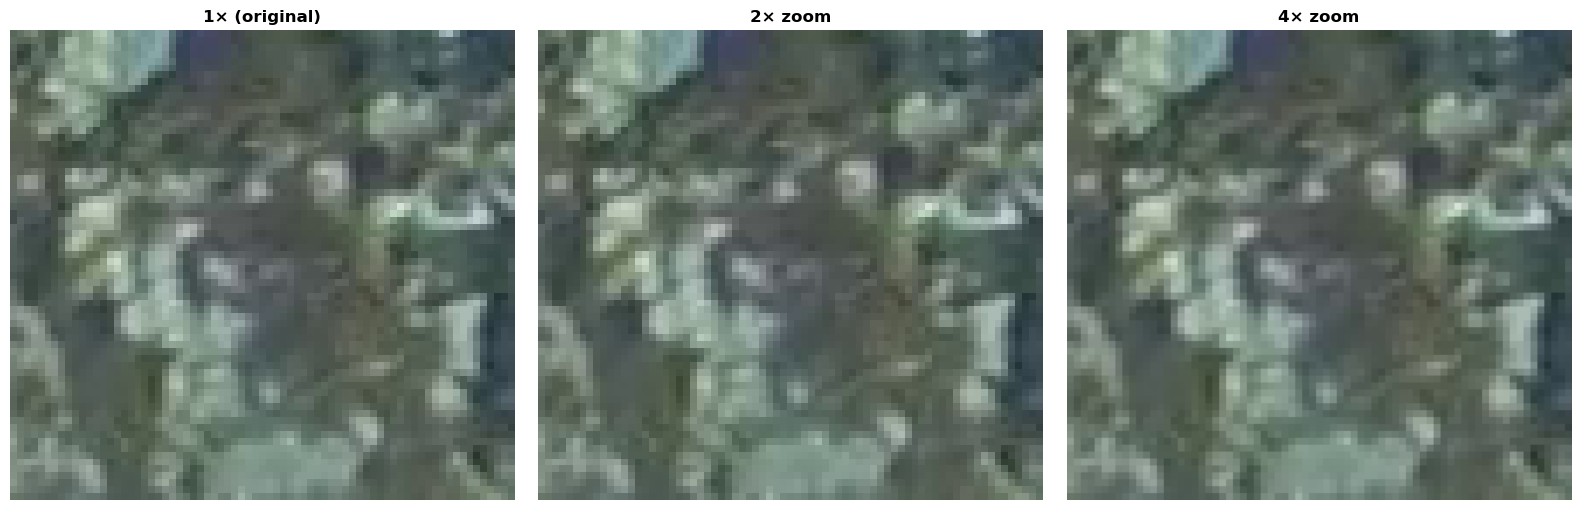

Detection 1 / 13139  |  Conf: 0.461  |  Video: CAMHDA301-20241001T031500  |  Frame: frame_0001.png  |  Box: [1285, 461, 1317, 489]  |  Status: ⚪ unlabeled


Progress: [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0%  (0/13139)  |  🟢 0 worms  |  🔴 0 not-worm  |  🟡 0 skipped


In [10]:
# ── Load saved progress if resuming ─────────────────────────────────
SAVE_PATH = WORK_DIR / "verification_progress.json"

if SAVE_PATH.exists():
    with open(SAVE_PATH) as f:
        saved = json.load(f)
    # Restore labels
    for i, label in saved.get("labels", {}).items():
        idx = int(i)
        if idx < len(all_detections):
            all_detections[idx]["label"] = label
    print(f"Resumed progress: {len(saved.get('labels', {}))} detections already labeled")
else:
    print("Starting fresh — no saved progress found.")


def save_progress():
    """Save current labels to disk."""
    labels = {}
    for i, det in enumerate(all_detections):
        if det["label"] is not None:
            labels[str(i)] = det["label"]
    with open(SAVE_PATH, "w") as f:
        json.dump({"labels": labels}, f, indent=2)


# ── Verification widget ────────────────────────────────────────────
# Find first unlabeled detection
current_idx = [0]
for i, det in enumerate(all_detections):
    if det["label"] is None:
        current_idx[0] = i
        break

# Display areas
output_images = widgets.Output(layout=widgets.Layout(width="100%"))
output_info = widgets.Output(layout=widgets.Layout(width="100%"))
output_progress = widgets.Output(layout=widgets.Layout(width="100%"))

# Buttons
btn_worm = widgets.Button(
    description="✓ Scale Worm",
    button_style="success",
    layout=widgets.Layout(width="180px", height="50px"),
    style={"font_weight": "bold"},
)
btn_not_worm = widgets.Button(
    description="✗ Not a Worm",
    button_style="danger",
    layout=widgets.Layout(width="180px", height="50px"),
    style={"font_weight": "bold"},
)
btn_skip = widgets.Button(
    description="⟳ Skip",
    button_style="warning",
    layout=widgets.Layout(width="120px", height="50px"),
)
btn_prev = widgets.Button(
    description="◀ Previous",
    layout=widgets.Layout(width="120px", height="50px"),
)


def show_detection(idx):
    """Display the current detection at multiple resolutions."""
    det = all_detections[idx]
    crop = np.array(Image.open(det["crop_path"]))

    with output_images:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # 1× — original size
        axes[0].imshow(crop)
        axes[0].set_title("1× (original)", fontsize=12, fontweight="bold")
        axes[0].axis("off")

        # 2× — scaled up
        crop_2x = np.array(Image.fromarray(crop).resize(
            (crop.shape[1] * 2, crop.shape[0] * 2), Image.NEAREST))
        axes[1].imshow(crop_2x)
        axes[1].set_title("2× zoom", fontsize=12, fontweight="bold")
        axes[1].axis("off")

        # 4× — scaled up
        crop_4x = np.array(Image.fromarray(crop).resize(
            (crop.shape[1] * 4, crop.shape[0] * 4), Image.NEAREST))
        axes[2].imshow(crop_4x)
        axes[2].set_title("4× zoom", fontsize=12, fontweight="bold")
        axes[2].axis("off")

        fig.tight_layout()
        plt.show()

    with output_info:
        clear_output(wait=True)
        label_str = det["label"] or "unlabeled"
        label_color = {"scale_worm": "🟢", "not_worm": "🔴", "skip": "🟡"}.get(
            det["label"], "⚪")
        print(f"Detection {idx + 1} / {len(all_detections)}  |  "
              f"Conf: {det['conf']:.3f}  |  "
              f"Video: {det['video']}  |  "
              f"Frame: {det['frame_file']}  |  "
              f"Box: [{det['x1']:.0f}, {det['y1']:.0f}, {det['x2']:.0f}, {det['y2']:.0f}]  |  "
              f"Status: {label_color} {label_str}")

    update_progress()


def update_progress():
    """Show progress bar."""
    n_done = sum(1 for d in all_detections if d["label"] is not None)
    n_worm = sum(1 for d in all_detections if d["label"] == "scale_worm")
    n_not = sum(1 for d in all_detections if d["label"] == "not_worm")
    n_skip = sum(1 for d in all_detections if d["label"] == "skip")
    n_total = len(all_detections)
    pct = 100 * n_done / max(n_total, 1)

    with output_progress:
        clear_output(wait=True)
        bar = "█" * int(pct / 2) + "░" * (50 - int(pct / 2))
        print(f"Progress: [{bar}] {pct:.0f}%  "
              f"({n_done}/{n_total})  |  "
              f"🟢 {n_worm} worms  |  🔴 {n_not} not-worm  |  🟡 {n_skip} skipped")


def advance():
    """Move to the next unlabeled detection."""
    start = current_idx[0]
    for offset in range(1, len(all_detections) + 1):
        candidate = (start + offset) % len(all_detections)
        if all_detections[candidate]["label"] is None:
            current_idx[0] = candidate
            show_detection(current_idx[0])
            return
    # All labeled
    current_idx[0] = len(all_detections) - 1
    show_detection(current_idx[0])
    with output_info:
        print("\n🎉  ALL DETECTIONS VERIFIED!  Proceed to Step 7 to export.")


def on_worm(b):
    all_detections[current_idx[0]]["label"] = "scale_worm"
    save_progress()
    advance()

def on_not_worm(b):
    all_detections[current_idx[0]]["label"] = "not_worm"
    save_progress()
    advance()

def on_skip(b):
    all_detections[current_idx[0]]["label"] = "skip"
    save_progress()
    advance()

def on_prev(b):
    if current_idx[0] > 0:
        current_idx[0] -= 1
    show_detection(current_idx[0])


btn_worm.on_click(on_worm)
btn_not_worm.on_click(on_not_worm)
btn_skip.on_click(on_skip)
btn_prev.on_click(on_prev)

# Layout
button_bar = widgets.HBox(
    [btn_prev, btn_worm, btn_not_worm, btn_skip],
    layout=widgets.Layout(justify_content="center", gap="10px"),
)

ui = widgets.VBox([
    output_progress,
    output_images,
    output_info,
    button_bar,
])

display(ui)
show_detection(current_idx[0])

## 7. Summary

<span style="font-family: 'Courier New', monospace;">

Run this cell at any time to see a summary of your verification work.

</span>

In [8]:
n_total = len(all_detections)
n_worm = sum(1 for d in all_detections if d["label"] == "scale_worm")
n_not = sum(1 for d in all_detections if d["label"] == "not_worm")
n_skip = sum(1 for d in all_detections if d["label"] == "skip")
n_unlabeled = sum(1 for d in all_detections if d["label"] is None)

print("=" * 60)
print("VERIFICATION SUMMARY")
print("=" * 60)
print(f"  Total detections:     {n_total:,}")
print(f"  ✓ Scale worm:         {n_worm:,} ({100*n_worm/max(n_total,1):.1f}%)")
print(f"  ✗ Not a worm:         {n_not:,} ({100*n_not/max(n_total,1):.1f}%)")
print(f"  ⟳ Skipped:            {n_skip:,}")
print(f"  ⚪ Unlabeled:          {n_unlabeled:,}")
print(f"  False positive rate:  {100*n_not/max(n_worm+n_not,1):.1f}%")
print("=" * 60)

if n_unlabeled > 0:
    print(f"\n⚠️  {n_unlabeled} detections still unlabeled. "
          "Go back to Step 6 to finish before exporting.")

VERIFICATION SUMMARY
  Total detections:     3,874
  ✓ Scale worm:         3,610 (93.2%)
  ✗ Not a worm:         88 (2.3%)
  ⟳ Skipped:            176
  ⚪ Unlabeled:          0
  False positive rate:  2.4%


## 8. Export verified detections as YOLO dataset

<span style="font-family: 'Courier New', monospace;">

This cell builds a YOLO-format dataset zip containing only the verified true detections. The zip file can be used directly for downstream YOLO training.

**YOLO format**: Each image gets a matching `.txt` label file. Each line in the label file is:
```
class_id  center_x  center_y  width  height
```
All coordinates are normalized to [0, 1] relative to the image dimensions (1920×1080).

</span>

In [9]:
def pixel_to_yolo(x1, y1, x2, y2, img_w=FRAME_W, img_h=FRAME_H):
    """Convert pixel coords (x1, y1, x2, y2) to YOLO normalized (cx, cy, w, h)."""
    cx = ((x1 + x2) / 2) / img_w
    cy = ((y1 + y2) / 2) / img_h
    w = (x2 - x1) / img_w
    h = (y2 - y1) / img_h
    # Clamp to [0, 1]
    cx = max(0.0, min(1.0, cx))
    cy = max(0.0, min(1.0, cy))
    w = max(0.0, min(1.0, w))
    h = max(0.0, min(1.0, h))
    return cx, cy, w, h


# Group verified worm detections by source frame
worm_dets = [d for d in all_detections if d["label"] == "scale_worm"]

if len(worm_dets) == 0:
    print("No verified worm detections to export!")
else:
    # Group by frame_path
    from collections import defaultdict
    frame_groups = defaultdict(list)
    for det in worm_dets:
        frame_groups[det["frame_path"]].append(det)

    # Build YOLO dataset directory
    img_dir = EXPORT_DIR / "images" / "train"
    lbl_dir = EXPORT_DIR / "labels" / "train"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    # Copy frames and write label files
    for frame_path, dets in sorted(frame_groups.items()):
        src = Path(frame_path)
        # Use video_name + frame_name for unique filenames
        video_name = dets[0]["video"]
        frame_name = dets[0]["frame_file"]
        unique_name = f"{video_name}_{frame_name}"
        stem = Path(unique_name).stem

        # Copy image
        dst_img = img_dir / unique_name
        if not dst_img.exists():
            shutil.copy2(src, dst_img)

        # Write label file
        dst_lbl = lbl_dir / f"{stem}.txt"
        with open(dst_lbl, "w") as f:
            for det in dets:
                cx, cy, w, h = pixel_to_yolo(det["x1"], det["y1"],
                                              det["x2"], det["y2"])
                f.write(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

    # Write dataset.yaml
    yaml_path = EXPORT_DIR / "dataset.yaml"
    with open(yaml_path, "w") as f:
        f.write(f"path: .\n")
        f.write(f"train: images/train\n")
        f.write(f"val: images/train\n\n")  # same split — user can reorganize
        f.write(f"nc: 1\n")
        f.write(f"names:\n")
        f.write(f"  0: scale_worm\n\n")
        f.write(f"# Verified detections: {len(worm_dets)}\n")
        f.write(f"# Source frames: {len(frame_groups)}\n")
        f.write(f"# Date range: {START_DATE} to {END_DATE}\n")
        f.write(f"# Confidence threshold: {CONF_THRESHOLD}\n")
        f.write(f"# Frame size: {FRAME_W}x{FRAME_H}\n")

    # Create zip
    zip_name = f"verified_scaleworm_dataset_{START_DATE}_to_{END_DATE}.zip"
    zip_path = WORK_DIR / zip_name

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for fpath in sorted(EXPORT_DIR.rglob("*")):
            if fpath.is_file():
                arcname = fpath.relative_to(EXPORT_DIR)
                zf.write(fpath, arcname)

    zip_size_mb = zip_path.stat().st_size / 1e6

    print("=" * 60)
    print("EXPORT COMPLETE")
    print("=" * 60)
    print(f"  Verified worm detections: {len(worm_dets):,}")
    print(f"  Unique frames:            {len(frame_groups):,}")
    print(f"  YOLO dataset:             {EXPORT_DIR}")
    print(f"  Zip file:                 {zip_path}")
    print(f"  Zip size:                 {zip_size_mb:.1f} MB")
    print("=" * 60)
    print(f"\nTo use this dataset for YOLO training:")
    print(f"  yolo detect train data=dataset.yaml model=yolo11m.pt epochs=20 imgsz=1920")

EXPORT COMPLETE
  Verified worm detections: 3,610
  Unique frames:            1,153
  YOLO dataset:             verification_session/export
  Zip file:                 verification_session/verified_scaleworm_dataset_2024-10-01_to_2024-10-31.zip
  Zip size:                 4767.3 MB

To use this dataset for YOLO training:
  yolo detect train data=dataset.yaml model=yolo11m.pt epochs=20 imgsz=1920


## 9. Import corrected annotations from Ultralytics Hub

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

After uploading your exported zip to [Ultralytics Hub](https://hub.ultralytics.com), correcting the bounding boxes, and downloading the result, run this cell to convert the annotations back into YOLO format for retraining.

**What the `.ndjson` file is:**
It contains one JSON record per image with corrected bounding box positions. It is *annotation data* — it tells the model *where* worms are in each image, not what the model weights are. The retraining step (Section 10) uses this to update the model.

**Steps before running this cell:**
1. In Ultralytics Hub, export your corrected dataset as `.ndjson`
2. Download the file and place it somewhere accessible (e.g., `verification_session/`)
3. Set `NDJSON_PATH` below to the file's path
4. `IMAGES_DIR` defaults to the images exported in Step 8 — change it only if you moved them

</span>

In [5]:
# ── CONFIGURATION ─────────────────────────────────────────────────
# Path to the .ndjson file downloaded from Ultralytics Hub
# Use an absolute path — the notebook CWD is notebooks/, not the repo root
NDJSON_PATH = Path("/home/jovyan/scaleworm-student-lab/round_2.ndjson")

# Directory containing the original exported images (from Step 8)
IMAGES_DIR = EXPORT_DIR / "images" / "train"

# Output directory for the corrected YOLO dataset
CORRECTED_DIR = WORK_DIR / "corrected_dataset"
# ──────────────────────────────────────────────────────────────────

if not NDJSON_PATH.exists():
    raise FileNotFoundError(
        f"NDJSON file not found: {NDJSON_PATH}\n"
        "Set NDJSON_PATH above to the path of your downloaded .ndjson file."
    )

# ── Preview the first image record so you can verify the format ───
print("=== NDJSON SAMPLE (first image record) ===")
with open(NDJSON_PATH) as _f:
    for _line in _f:
        _rec = json.loads(_line.strip())
        if _rec.get("type") == "image":
            print(json.dumps(_rec, indent=2)[:1200])
            break
print("=" * 40)
print("If the structure above looks wrong, stop here and check your export settings.\n")


# ── Parse .ndjson and build YOLO dataset ──────────────────────────
img_out = CORRECTED_DIR / "images" / "train"
lbl_out = CORRECTED_DIR / "labels" / "train"
img_out.mkdir(parents=True, exist_ok=True)
lbl_out.mkdir(parents=True, exist_ok=True)

n_images = 0
n_boxes = 0
n_missing = 0

with open(NDJSON_PATH) as f:
    for line_num, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue

        record = json.loads(line)

        # Skip non-image records (e.g. the dataset metadata header line)
        if record.get("type") != "image":
            continue

        # Ultralytics Hub uses "file" key (not "filename" / "name")
        img_name = Path(record.get("file", "")).name
        if not img_name:
            print(f"  Line {line_num}: no 'file' field, skipping")
            continue

        # Hub may export with .jpg extension; local images are .png — try both
        src_img = IMAGES_DIR / img_name
        if not src_img.exists():
            stem = Path(img_name).stem
            alt = IMAGES_DIR / f"{stem}.png"
            if alt.exists():
                src_img = alt
                img_name = alt.name  # use the .png filename going forward
            else:
                n_missing += 1
                if n_missing <= 5:
                    print(f"  WARNING: image not found: {img_name}")
                continue

        img_w = record.get("width", FRAME_W)
        img_h = record.get("height", FRAME_H)

        # Hub format: {"annotations": {"boxes": [[cls, cx, cy, w, h], ...]}}
        # Boxes are already in normalized YOLO format — no coordinate conversion needed.
        ann_data = record.get("annotations", {})
        raw_boxes = ann_data.get("boxes", []) if isinstance(ann_data, dict) else []
        if not raw_boxes:
            continue

        yolo_lines = []
        for box in raw_boxes:
            if len(box) == 5:
                cls, cx, cy, bw, bh = box
                yolo_lines.append(f"{int(cls)} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
            else:
                print(f"  Line {line_num}: unexpected box length {len(box)}, skipping")

        if not yolo_lines:
            continue

        # Copy image and write label file
        dst_img = img_out / img_name
        if not dst_img.exists():
            shutil.copy2(src_img, dst_img)

        stem = Path(img_name).stem
        (lbl_out / f"{stem}.txt").write_text("\n".join(yolo_lines) + "\n")

        n_images += 1
        n_boxes += len(yolo_lines)

# Write dataset.yaml
yaml_path = CORRECTED_DIR / "dataset.yaml"
yaml_path.write_text(
    f"path: .\n"
    f"train: images/train\n"
    f"val: images/train\n\n"
    f"nc: 1\n"
    f"names:\n"
    f"  0: scale_worm\n\n"
    f"# Source: corrected Ultralytics Hub annotations\n"
    f"# NDJSON: {NDJSON_PATH.name}\n"
    f"# Images: {n_images}  |  Boxes: {n_boxes}\n"
)

print(f"\n{'='*60}")
print("CORRECTED DATASET READY")
print(f"{'='*60}")
print(f"  Images with annotations: {n_images:,}")
print(f"  Total bounding boxes:    {n_boxes:,}")
if n_missing:
    print(f"  ⚠️  Images not found:     {n_missing}  (check IMAGES_DIR)")
print(f"  Output directory:        {CORRECTED_DIR}")
print(f"{'='*60}")
print("\nIf the counts look right, proceed to Section 10 to retrain.")

=== NDJSON SAMPLE (first image record) ===
{
  "type": "image",
  "file": "CAMHDA301-20241002T031500_frame_0003.jpg",
  "url": "https://cdn.ul.run/us/i/47920011a9ed14e9ea3c67b275a9976a.jpg?Expires=1781718247&KeyName=key-v1&Signature=DVhjwiKIAmJgbeTUftsza3k-G_M",
  "width": 1920,
  "height": 1080,
  "split": "train",
  "annotations": {
    "boxes": [
      [
        0,
        0.36773,
        0.57391,
        0.04363,
        0.06853
      ],
      [
        0,
        0.1523,
        0.29906,
        0.05571,
        0.06848
      ],
      [
        0,
        0.1951,
        0.77427,
        0.02664,
        0.10469
      ],
      [
        0,
        0.27251,
        0.79538,
        0.03648,
        0.07672
      ]
    ]
  }
}
If the structure above looks wrong, stop here and check your export settings.




CORRECTED DATASET READY
  Images with annotations: 1,156
  Total bounding boxes:    4,823
  Output directory:        verification_session/corrected_dataset

If the counts look right, proceed to Section 10 to retrain.


## 10. Retrain model on corrected annotations

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

This cell fine-tunes `mushroom.pt` on your corrected dataset. Fine-tuning starts from the existing model's weights and continues training on the new data — it does **not** start from scratch, so it converges quickly.

**What gets produced:**
A new `best.pt` file saved under `verification_session/runs/<run_name>/weights/`. Once training completes, update `MODEL_PATH` in Cell 1 (Section 1) to point to this file, then **restart the kernel and run from the top** — your improved model will be used for all future detections.

**Training time:** Roughly 5–20 minutes depending on dataset size and GPU availability on this Hub.

**Parameters you can adjust:**
- `RETRAIN_EPOCHS` — more epochs = longer training, potentially better accuracy (default 20)
- `RETRAIN_IMGSZ` — image size during training; 1280 is a good balance (original frames are 1920)
- `RETRAIN_RUN_NAME` — name of the output folder under `runs/`

</span>

In [ ]:
# ── CONFIGURATION ─────────────────────────────────────────────────
RETRAIN_EPOCHS   = 20       # Training epochs (more = slower but potentially better)
RETRAIN_IMGSZ    = 1280     # Image size fed to the model during training
RETRAIN_RUN_NAME = "scaleworm_retrained_v2"  # Output folder name under runs/
# ──────────────────────────────────────────────────────────────────

yaml_path = CORRECTED_DIR / "dataset.yaml"
if not yaml_path.exists():
    raise FileNotFoundError(
        "Corrected dataset not found. Run Section 9 first to convert your .ndjson file."
    )

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Base model not found: {MODEL_PATH}")

runs_dir = WORK_DIR / "runs"
runs_dir.mkdir(parents=True, exist_ok=True)

print(f"Starting fine-tune of {MODEL_PATH.name}")
print(f"  Dataset:  {yaml_path}")
print(f"  Epochs:   {RETRAIN_EPOCHS}")
print(f"  Img size: {RETRAIN_IMGSZ}")
print(f"  Output:   {runs_dir / RETRAIN_RUN_NAME}\n")

retrain_model = YOLO(str(MODEL_PATH))

train_results = retrain_model.train(
    data=str(yaml_path),
    epochs=RETRAIN_EPOCHS,
    imgsz=RETRAIN_IMGSZ,
    name=RETRAIN_RUN_NAME,
    project=str(runs_dir),
    workers=4,     # capped — Hub containers are CPU-limited
    exist_ok=True, # allow re-running without renaming
)

best_weights = Path(train_results.save_dir) / "weights" / "best.pt"

print(f"\n{'='*60}")
print("RETRAINING COMPLETE")
print(f"{'='*60}")
print(f"  Best weights: {best_weights}")
print(f"  Exists:       {best_weights.exists()}")
print(f"{'='*60}")
print()
print("Next steps:")
print("  1. In Cell 1 (Section 1), update MODEL_PATH to:")
print(f"       MODEL_PATH = Path('{best_weights}')")
print("  2. Restart the kernel (Kernel → Restart Kernel)")
print("  3. Run all cells from the top — your improved model will be used")